In [12]:
# Import necessary libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

# Your code here

# Load dataset
data = pd.read_csv('diabetes.csv')

# Split data into features and target
X = data.drop('Outcome', axis=1)
y = data['Outcome']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_test)

# Calculate accuracy
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"Random Forest Accuracy: {rf_accuracy}")


Random Forest Accuracy: 0.7207792207792207


In [13]:
# Import necessary libraries
from sklearn.ensemble import GradientBoostingClassifier

# Train Gradient Boosting model
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

# Make predictions
gb_predictions = gb_model.predict(X_test)

# Calculate accuracy
gb_accuracy = accuracy_score(y_test, gb_predictions)
print(f"Gradient Boosting Accuracy: {gb_accuracy}")

Gradient Boosting Accuracy: 0.7467532467532467


In [14]:
# Import necessary libraries
from sklearn.ensemble import AdaBoostClassifier

# Train AdaBoost model
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train, y_train)

# Make predictions
ada_predictions = ada_model.predict(X_test)

# Calculate accuracy
ada_accuracy = accuracy_score(y_test, ada_predictions)
print(f"AdaBoost Accuracy: {ada_accuracy}")


AdaBoost Accuracy: 0.7402597402597403


In [15]:
# Import necessary libraries
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Define base models
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('ada', AdaBoostClassifier(n_estimators=100, random_state=42))
]

# Define meta-learner (Logistic Regression)
stacked_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(),
    cv=5
)

# Train stacked model
stacked_model.fit(X_train, y_train)

# Make predictions
stacked_predictions = stacked_model.predict(X_test)

# Calculate accuracy
stacked_accuracy = accuracy_score(y_test, stacked_predictions)
print(f"Stacked Model Accuracy: {stacked_accuracy}")


Stacked Model Accuracy: 0.7467532467532467


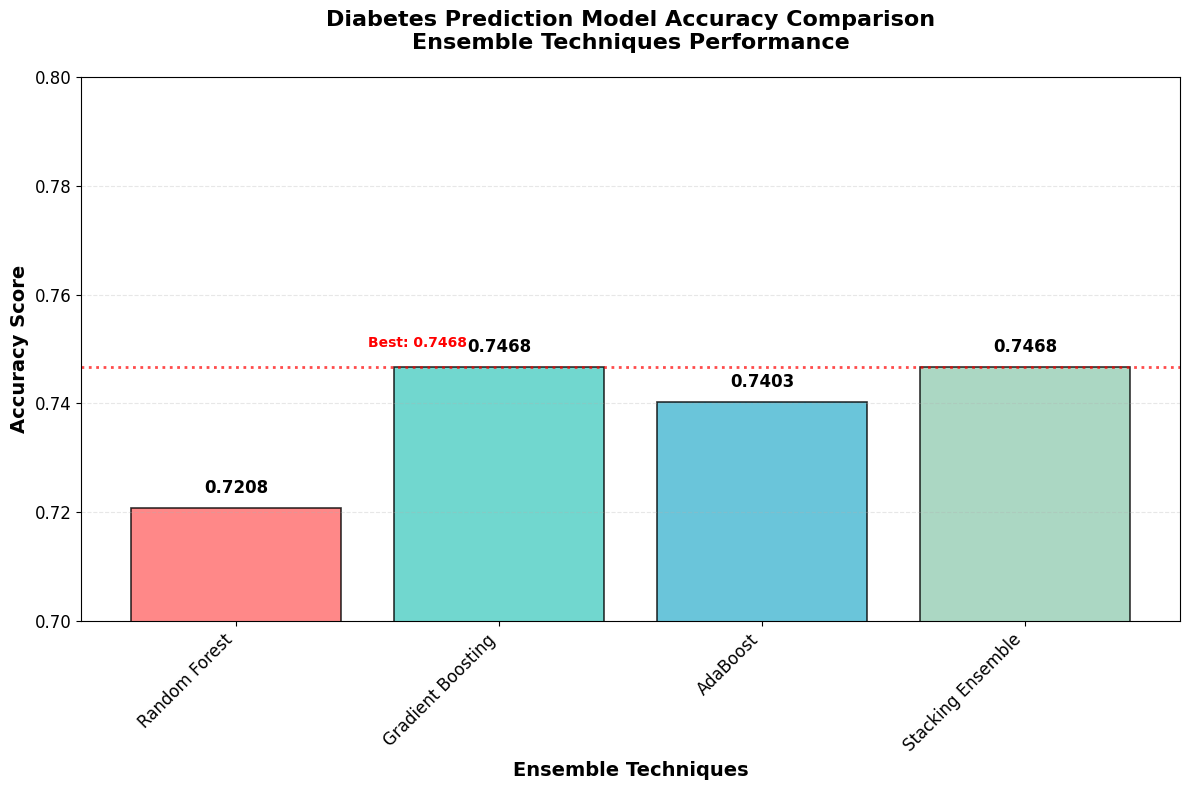


ENSEMBLE TECHNIQUES ACCURACY SUMMARY
Random Forest       : 0.7208 (72.08%)
Gradient Boosting   : 0.7468 (74.68%)
AdaBoost            : 0.7403 (74.03%)
Stacking Ensemble   : 0.7468 (74.68%)

Best performing model: Gradient Boosting
Worst performing model: Random Forest
Accuracy range: 0.0260


In [16]:
# Create visualization comparing ensemble techniques
import matplotlib.pyplot as plt
import numpy as np

# Store accuracy values
models = ['Random Forest', 'Gradient Boosting', 'AdaBoost', 'Stacking Ensemble']
accuracies = [rf_accuracy, gb_accuracy, ada_accuracy, stacked_accuracy]

# Create the bar chart
plt.figure(figsize=(12, 8))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
bars = plt.bar(models, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)

# Customize the plot
plt.title('Diabetes Prediction Model Accuracy Comparison\nEnsemble Techniques Performance', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Ensemble Techniques', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy Score', fontsize=14, fontweight='bold')
plt.ylim(0.7, 0.8)  # Set y-axis limits for better visualization

# Add value labels on top of bars
for bar, accuracy in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.002,
             f'{accuracy:.4f}', ha='center', va='bottom', 
             fontsize=12, fontweight='bold')

# Add grid for better readability
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Customize tick labels
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Add a horizontal line showing the best performance
best_accuracy = max(accuracies)
plt.axhline(y=best_accuracy, color='red', linestyle=':', alpha=0.7, linewidth=2)
plt.text(0.5, best_accuracy + 0.003, f'Best: {best_accuracy:.4f}', 
         ha='left', va='bottom', color='red', fontweight='bold')

# Tight layout and show
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*50)
print("ENSEMBLE TECHNIQUES ACCURACY SUMMARY")
print("="*50)
for model, acc in zip(models, accuracies):
    print(f"{model:<20}: {acc:.4f} ({acc*100:.2f}%)")

print(f"\nBest performing model: {models[accuracies.index(max(accuracies))]}")
print(f"Worst performing model: {models[accuracies.index(min(accuracies))]}")
print(f"Accuracy range: {max(accuracies) - min(accuracies):.4f}")

In [11]:
import joblib

# Assuming you choose the stacked model as the best one
joblib.dump(stacked_model, 'diabetes_ensemble_model.pkl')

['diabetes_ensemble_model.pkl']